# Практическая работа 9: Плотностная кластеризация | `Target` и зашумленный `Hepta`

## 1. Импорты и конфигурация

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
NOISE_SCALE_RANGE = (2.0, 4.0)
NOISE_FRACTIONS = (0.01, 0.03, 0.05, 0.10)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 11
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

NOTEBOOK_DIR = Path.cwd()
HEPTA_PATH = NOTEBOOK_DIR / "hepta.csv"
TARGET_PATH = NOTEBOOK_DIR / "target.csv"

HEPTA_PATH, TARGET_PATH

(PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-ИАД-2025/Практика/Практика 9 - Плотностная кластеризация/hepta.csv'),
 PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-ИАД-2025/Практика/Практика 9 - Плотностная кластеризация/target.csv'))

## 2. Описание данных

В работе используются два benchmark-набора из семейства FCPS.

Набор `Hepta` используется как трехмерная выпуклая структура, на основе которой формируются
зашумленные модификации для анализа устойчивости плотностной кластеризации к выбросам. В рамках шумового эксперимента из набора `Hepta` формируются четыре искаженные модификации
с долями зашумления `1%`, `3%`, `5%` и `10%`.

Набор `Target` рассматривается как двумерная невыпуклая структура, для которой алгоритм `DBSCAN`
должен демонстрировать преимущество за счет выделения кластеров произвольной формы.


## 3. Загрузка датасетов

In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Загружает CSV-файл с benchmark-набором данных.

    Parameters
    ----------
    path : Path
        Путь к CSV-файлу с данными.

    Returns
    -------
    pd.DataFrame
        Таблица наблюдений в исходной структуре CSV-файла.
    """
    return pd.read_csv(path)

In [3]:
target_df = load_dataset(TARGET_PATH)
hepta_df = load_dataset(HEPTA_PATH)

In [4]:
pd.DataFrame(
    [
        {
            "dataset": "Target",
            "n_objects": len(target_df),
            "n_features": len([column for column in target_df.columns if column.startswith("x")]),
            "n_reference_clusters": target_df["true_cluster"].nunique(),
        },
        {
            "dataset": "Hepta",
            "n_objects": len(hepta_df),
            "n_features": len([column for column in hepta_df.columns if column.startswith("x")]),
            "n_reference_clusters": hepta_df["true_cluster"].nunique(),
        },
    ]
)

,dataset,n_objects,n_features,n_reference_clusters
0,Target,770,2,6
1,Hepta,212,3,7


In [5]:
target_df.head()

,object_id,x1,x2,true_cluster
0,1,-3.0000,-3.0000,5
1,2,-3.0000,3.0000,4
2,3,3.0000,-3.0000,6
3,4,3.0000,3.0000,3
4,5,-0.4171,0.1148,1


In [6]:
hepta_df.head()

,object_id,x1,x2,x3,true_cluster
0,1,-0.0633,0.0277,0.0227,1
1,2,-0.0007,0.0482,0.0692,1
2,3,-0.0608,-0.0091,0.0531,1
3,4,0.0133,-0.0119,0.0553,1
4,5,-0.0545,-0.0038,0.0017,1


In [7]:
target_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   object_id     770 non-null    int64  
 1   x1            770 non-null    float64
 2   x2            770 non-null    float64
 3   true_cluster  770 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 24.2 KB


In [8]:
hepta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   object_id     212 non-null    int64  
 1   x1            212 non-null    float64
 2   x2            212 non-null    float64
 3   x3            212 non-null    float64
 4   true_cluster  212 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 8.4 KB


## 4. Подготовка данных и вспомогательные функции

In [9]:
def standardize_features(
    data: pd.DataFrame,
    feature_columns: list[str],
    fitted_scaler: StandardScaler | None = None,
) -> tuple[pd.DataFrame, StandardScaler]:
    """Стандартизует признаки набора данных.

    Parameters
    ----------
    data : pd.DataFrame
        Исходная таблица наблюдений.
    feature_columns : list[str]
        Список стандартизируемых признаков.
    fitted_scaler : StandardScaler | None, default=None
        Уже обученный scaler. Если не задан, scaler обучается на текущем наборе.

    Returns
    -------
    tuple[pd.DataFrame, StandardScaler]
        Стандартизованная таблица и использованный объект scaler.
    """
    scaler = fitted_scaler or StandardScaler()
    transformed = data.copy()
    if fitted_scaler is None:
        transformed[feature_columns] = scaler.fit_transform(transformed[feature_columns])
    else:
        transformed[feature_columns] = scaler.transform(transformed[feature_columns])
    return transformed, scaler

In [10]:
def add_sparse_outlier_noise(
    data: pd.DataFrame,
    feature_columns: list[str],
    fraction: float,
    random_state: int,
    scale_range: tuple[float, float] = NOISE_SCALE_RANGE,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Вносит локальные выбросы в случайно выбранную долю наблюдений.

    Parameters
    ----------
    data : pd.DataFrame
        Исходный набор данных.
    feature_columns : list[str]
        Признаки, по которым допускается искажение.
    fraction : float
        Доля искажаемых объектов.
    random_state : int
        Значение генератора случайных чисел.
    scale_range : tuple[float, float], default=NOISE_SCALE_RANGE
        Интервал амплитуд шума в единицах стандартного отклонения.

    Returns
    -------
    tuple[pd.DataFrame, np.ndarray]
        Зашумленный набор данных и индексы искаженных объектов.
    """
    rng = np.random.default_rng(random_state)
    noisy = data.copy()
    feature_stds = noisy[feature_columns].std(axis=0, ddof=0).to_numpy()
    n_noisy = max(1, int(round(len(noisy) * fraction)))
    noisy_indices = np.sort(rng.choice(len(noisy), size=n_noisy, replace=False))

    for row_index in noisy_indices:
        n_dimensions = int(rng.integers(1, len(feature_columns) + 1))
        selected_positions = rng.choice(len(feature_columns), size=n_dimensions, replace=False)
        magnitudes = rng.uniform(scale_range[0], scale_range[1], size=n_dimensions) * feature_stds[selected_positions]
        signs = rng.choice([-1.0, 1.0], size=n_dimensions)

        for position, delta in zip(selected_positions, signs * magnitudes):
            column = feature_columns[position]
            noisy.loc[row_index, column] += float(delta)

    return noisy, noisy_indices

In [11]:
def propose_eps_values(
    data: pd.DataFrame,
    feature_columns: list[str],
    n_neighbors: int = 10,
    n_values: int = 24,
) -> np.ndarray:
    """Формирует сетку значений `eps` по эвристике k-distance.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для оценки радиуса соседства.
    feature_columns : list[str]
        Числовые признаки.
    n_neighbors : int, default=10
        Число соседей для оценки характерных расстояний.
    n_values : int, default=24
        Число точек в формируемой сетке.

    Returns
    -------
    np.ndarray
        Одномерный массив кандидатных значений `eps`.
    """
    X = data[feature_columns].to_numpy()
    model = NearestNeighbors(n_neighbors=n_neighbors)
    model.fit(X)
    distances, _ = model.kneighbors(X)
    kth_distances = np.sort(distances[:, -1])
    low = max(float(np.quantile(kth_distances, 0.10)), 0.01)
    high = float(np.quantile(kth_distances, 0.95))
    if high <= low:
        high = low + 0.5
    return np.linspace(low, high, n_values)

In [12]:
def run_dbscan_grid(
    data: pd.DataFrame,
    feature_columns: list[str],
    eps_values: np.ndarray,
    min_samples_values: range,
) -> pd.DataFrame:
    """Выполняет серию запусков `DBSCAN` на сетке параметров.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для кластеризации.
    feature_columns : list[str]
        Числовые признаки.
    eps_values : np.ndarray
        Набор радиусов окрестности.
    min_samples_values : range
        Набор значений `min_samples`.

    Returns
    -------
    pd.DataFrame
        Таблица с метками кластеров, числом кластеров,
        долей шума и коэффициентом силуэта.
    """
    X = data[feature_columns].to_numpy()
    rows = []
    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=float(eps), min_samples=int(min_samples))
            labels = model.fit_predict(X)
            non_noise_mask = labels != -1
            valid_labels = labels[non_noise_mask]
            if non_noise_mask.sum() >= 2 and len(set(valid_labels.tolist())) >= 2:
                silhouette = float(silhouette_score(X[non_noise_mask], valid_labels))
            else:
                silhouette = np.nan
            n_clusters = len({label for label in labels.tolist() if label != -1})
            rows.append(
                {
                    "eps": float(eps),
                    "min_samples": int(min_samples),
                    "labels": labels,
                    "n_clusters": n_clusters,
                    "noise_ratio": float(np.mean(labels == -1)),
                    "silhouette": silhouette,
                }
            )
    return pd.DataFrame(rows)

In [13]:
def select_representative_dbscan_configs(results: pd.DataFrame) -> pd.DataFrame:
    """Выбирает конфигурации `DBSCAN`, пригодные для визуального анализа.

    Parameters
    ----------
    results : pd.DataFrame
        Таблица, полученная функцией `run_dbscan_grid`.

    Returns
    -------
    pd.DataFrame
        Подмножество строк с репрезентативными конфигурациями для
        каждого значения `min_samples`.

    Notes
    -----
    При отборе приоритет отдается минимальной доле шума, поскольку для
    набора `Target` максимизация силуэта сама по себе приводит к
    вырожденным решениям, в которых значительная часть внешнего кольца
    ошибочно относится к шуму. Среди конфигураций с одинаковой долей
    шума выбирается наименьшее число кластеров, чтобы избежать
    искусственной фрагментации структуры. Если таких конфигураций
    несколько, сохраняется минимальное значение `eps`, при котором уже
    достигается устойчивая кластерная схема.
    """
    rows = []
    for min_samples, subset in results.groupby("min_samples", sort=True):
        subset = subset[subset["n_clusters"] >= 2].copy()
        min_noise_ratio = subset["noise_ratio"].min()
        candidates = subset[np.isclose(subset["noise_ratio"], min_noise_ratio)].copy()
        stable_cluster_count = candidates["n_clusters"].min()
        stable_candidates = candidates[candidates["n_clusters"] == stable_cluster_count].copy()
        ranked = stable_candidates.sort_values(
            by=["eps", "silhouette"],
            ascending=[True, False],
            na_position="last",
        )
        rows.append(ranked.iloc[0])
    return pd.DataFrame(rows).reset_index(drop=True)

In [14]:
def plot_cluster_grid(
    data: pd.DataFrame,
    feature_columns: list[str],
    label_pairs: list[tuple[str, np.ndarray]],
    figure_title: str,
    n_columns: int = 4,
) -> None:
    """Строит панель точечных диаграмм для нескольких кластерных разбиений.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для визуализации.
    feature_columns : list[str]
        Используемые признаки.
    label_pairs : list[tuple[str, np.ndarray]]
        Пары вида `(заголовок, метки кластеров)`.
    figure_title : str
        Общий заголовок панели.
    n_columns : int, default=4
        Число столбцов в панели.
    """
    n_panels = len(label_pairs)
    n_rows = int(np.ceil(n_panels / n_columns))
    is_3d = len(feature_columns) == 3
    figure = plt.figure(figsize=(4.6 * n_columns, 4.2 * n_rows))
    palette = sns.color_palette("tab10", n_colors=12)

    for index, (title, labels) in enumerate(label_pairs, start=1):
        if is_3d:
            axis = figure.add_subplot(n_rows, n_columns, index, projection="3d")
        else:
            axis = figure.add_subplot(n_rows, n_columns, index)

        colors = []
        for label in labels:
            if label == -1:
                colors.append((0.15, 0.15, 0.15))
            else:
                colors.append(palette[int(label) % len(palette)])

        if is_3d:
            axis.scatter(
                data[feature_columns[0]],
                data[feature_columns[1]],
                data[feature_columns[2]],
                c=colors,
                s=18,
                alpha=0.85,
            )
            axis.set_xlabel(feature_columns[0])
            axis.set_ylabel(feature_columns[1])
            axis.set_zlabel(feature_columns[2])
        else:
            axis.scatter(
                data[feature_columns[0]],
                data[feature_columns[1]],
                c=colors,
                s=18,
                alpha=0.85,
            )
            axis.set_xlabel(feature_columns[0])
            axis.set_ylabel(feature_columns[1])

        axis.set_title(title)

    figure.suptitle(figure_title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
def select_noise_robust_dbscan_config(
    results: pd.DataFrame,
    reference_cluster_count: int,
) -> pd.Series:
    """Выбирает конфигурацию `DBSCAN` для анализа устойчивости к шуму.

    Parameters
    ----------
    results : pd.DataFrame
        Таблица, полученная функцией `run_dbscan_grid`.
    reference_cluster_count : int
        Ожидаемое число кластеров в базовой структуре набора данных.

    Returns
    -------
    pd.Series
        Одна строка таблицы результатов с выбранной конфигурацией.

    Notes
    -----
    Для зашумленного набора `Hepta` репрезентативной считается
    конфигурация, которая сохраняет число кластеров, максимально близкое
    к исходной семикластерной структуре, и при этом минимизирует долю
    шума. При равенстве выбирается наименьшее значение `eps`, при
    котором такая структура уже достигается.
    """
    candidates = results[results["n_clusters"] >= 2].copy()
    candidates["cluster_gap"] = (candidates["n_clusters"] - reference_cluster_count).abs()

    min_cluster_gap = candidates["cluster_gap"].min()
    candidates = candidates[candidates["cluster_gap"] == min_cluster_gap].copy()

    min_noise_ratio = candidates["noise_ratio"].min()
    candidates = candidates[np.isclose(candidates["noise_ratio"], min_noise_ratio)].copy()

    ranked = candidates.sort_values(
        by=["eps", "min_samples", "silhouette"],
        ascending=[True, True, False],
        na_position="last",
    )
    return ranked.iloc[0]

### 4.1. Стандартизация исследуемых наборов данных

In [16]:
target_scaled_df, _ = standardize_features(target_df, ["x1", "x2"])
hepta_scaled_df, hepta_scaler = standardize_features(hepta_df, ["x1", "x2", "x3"])

### 4.2. Формирование зашумленных модификаций набора `Hepta`

In [17]:
hepta_noisy_scaled = {}

for index, fraction in enumerate(NOISE_FRACTIONS, start=1):
    noisy_raw, noisy_indices = add_sparse_outlier_noise(
        data=hepta_df,
        feature_columns=["x1", "x2", "x3"],
        fraction=fraction,
        random_state=RANDOM_STATE + index,
    )
    noisy_scaled, _ = standardize_features(
        data=noisy_raw,
        feature_columns=["x1", "x2", "x3"],
        fitted_scaler=hepta_scaler,
    )
    hepta_noisy_scaled[fraction] = noisy_scaled.assign(is_noisy=noisy_scaled.index.isin(noisy_indices))

In [18]:
pd.DataFrame(
    [
        {
            "noise_fraction": fraction,
            "n_noisy_objects": int(dataset["is_noisy"].sum()),
        }
        for fraction, dataset in hepta_noisy_scaled.items()
    ]
)

,noise_fraction,n_noisy_objects
0,0.0100,2
1,0.0300,6
2,0.0500,11
3,0.1000,21


## 5. Эксперименты

### 5.1. Плотностная кластеризация невыпуклого набора `Target`

Для набора `Target` формируется сетка параметров `eps` и `min_samples`.
Из полной сетки затем выбираются репрезентативные конфигурации,
обеспечивающие наилучшее качество разбиения внутри каждого значения `min_samples`.

In [19]:
target_eps_values = propose_eps_values(target_scaled_df, ["x1", "x2"])
target_dbscan_results = run_dbscan_grid(
    data=target_scaled_df,
    feature_columns=["x1", "x2"],
    eps_values=target_eps_values,
    min_samples_values=range(3, 10),
)

In [20]:
target_dbscan_summary = select_representative_dbscan_configs(target_dbscan_results)[
    ["eps", "min_samples", "n_clusters", "noise_ratio", "silhouette", "labels"]
]
target_dbscan_summary.drop(columns="labels")

,eps,min_samples,n_clusters,noise_ratio,silhouette
0,0.2296,3,6,0.0000,0.2952
1,0.2296,4,2,0.0156,0.2844
2,0.2412,5,2,0.0156,0.2844
3,0.2760,6,2,0.0156,0.2844
4,0.2992,7,2,0.0156,0.2844
5,0.2992,8,2,0.0156,0.2844
6,0.2992,9,2,0.0156,0.2844


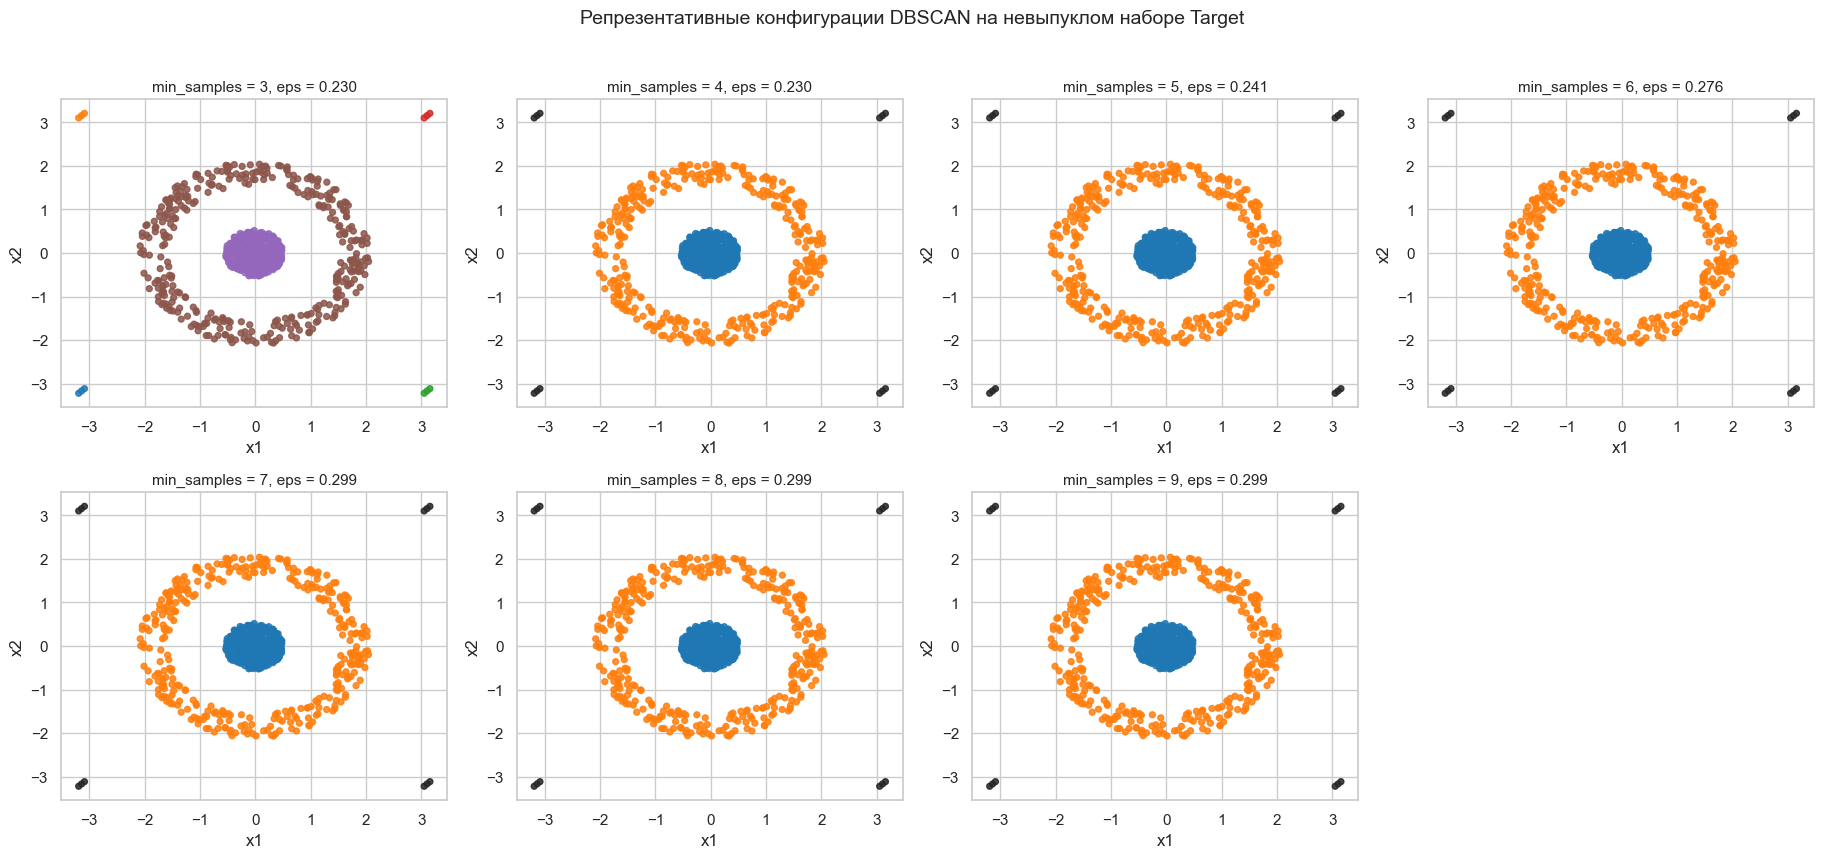

In [21]:
plot_cluster_grid(
    data=target_scaled_df,
    feature_columns=["x1", "x2"],
    label_pairs=[
        (
            f"min_samples = {int(row.min_samples)}, eps = {row.eps:.3f}",
            row.labels,
        )
        for row in target_dbscan_summary.itertuples()
    ],
    figure_title="Репрезентативные конфигурации DBSCAN на невыпуклом наборе Target",
)

### 5.2. Плотностная кластеризация зашумленного набора `Hepta`

На данном этапе анализируется устойчивость `DBSCAN` к тем же шумовым возмущениям,
которые были сформированы для набора `Hepta` в рамках общей исследовательской схемы.
Поскольку для benchmark-набора `Hepta` исходная семикластерная структура известна заранее,
репрезентативной считается конфигурация, которая сохраняет число кластеров, максимально
близкое к базовой структуре, и при этом не приводит к избыточной доле шума.

In [22]:
reference_cluster_count = hepta_df["true_cluster"].nunique()
hepta_dbscan_results = {}
hepta_dbscan_best = []

for fraction in NOISE_FRACTIONS:
    eps_values = propose_eps_values(hepta_noisy_scaled[fraction], ["x1", "x2", "x3"])
    results = run_dbscan_grid(
        data=hepta_noisy_scaled[fraction],
        feature_columns=["x1", "x2", "x3"],
        eps_values=eps_values,
        min_samples_values=range(3, 10),
    )
    hepta_dbscan_results[fraction] = results
    representative = select_noise_robust_dbscan_config(results, reference_cluster_count)
    hepta_dbscan_best.append(
        {
            "noise_fraction": fraction,
            "eps": representative["eps"],
            "min_samples": representative["min_samples"],
            "n_clusters": representative["n_clusters"],
            "noise_ratio": representative["noise_ratio"],
            "silhouette": representative["silhouette"],
            "labels": representative["labels"],
        }
    )

hepta_dbscan_best = pd.DataFrame(hepta_dbscan_best)

In [23]:
hepta_dbscan_best.drop(columns="labels")

,noise_fraction,eps,min_samples,n_clusters,noise_ratio,silhouette
0,0.0100,0.4591,3,7,0.0047,0.7019
1,0.0300,0.4599,3,7,0.0283,0.7013
2,0.0500,0.4752,3,7,0.0519,0.7022
3,0.1000,1.0463,3,7,0.0802,0.6941


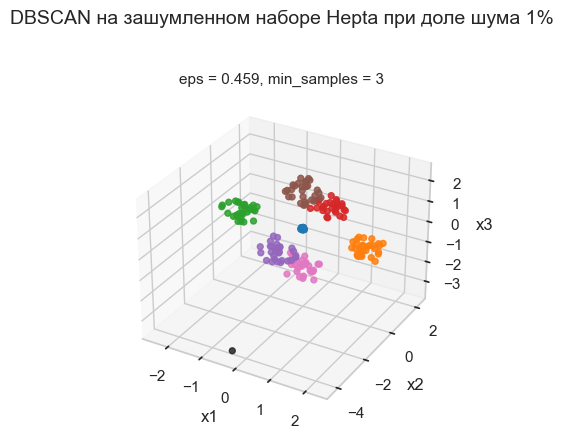

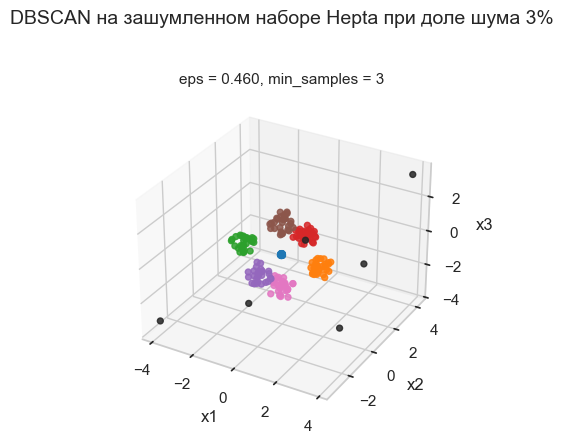

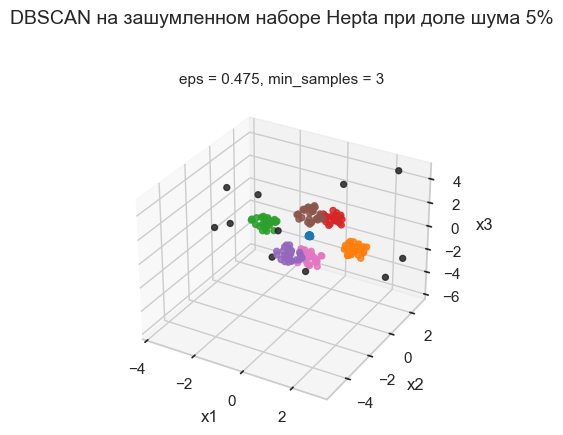

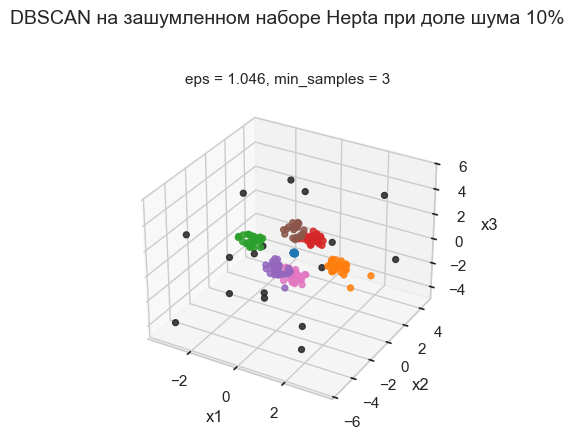

In [24]:
for row in hepta_dbscan_best.itertuples():
    plot_cluster_grid(
        data=hepta_noisy_scaled[row.noise_fraction],
        feature_columns=["x1", "x2", "x3"],
        label_pairs=[(
            f"eps = {row.eps:.3f}, min_samples = {int(row.min_samples)}",
            row.labels,
        )],
        figure_title=f"DBSCAN на зашумленном наборе Hepta при доле шума {row.noise_fraction:.0%}",
        n_columns=1,
    )

## 6. Вывод

На невыпуклом наборе `Target` алгоритм `DBSCAN` корректно выделяет кластеры произвольной формы,
что подтверждает его пригодность для плотностной кластеризации геометрически сложных структур.
На зашумленных модификациях `Hepta` при корректном выборе параметров `eps` и `min_samples`
алгоритм сохраняет исходную семикластерную макроструктуру и относит часть искаженных наблюдений
к шуму.